# DỰ BÁO BURNOUT LEVEL BẰNG MACHINE LEARNING

**Target:** `burnout_level`

**Bài toán:** Hồi quy Logistic

**Các thuật toán sử dụng:**
- Logistic Regression
- RandomForestClassifier
- CatBoost

1. Đọc và kiểm tra dữ liệu

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Đọc tập Train và Test
train_log_df = pd.read_csv('../data/data_preprocessing/burnout_train_standardized.csv')
test_log_df = pd.read_csv('../data/data_preprocessing/burnout_test_standardized.csv')

train_df = pd.read_csv('../data/burnout_train.csv')
test_df = pd.read_csv('../data/burnout_test.csv')

print("Train Standardized:", train_log_df.shape)
print("Test Standardized:", test_log_df.shape)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train Standardized: (76001, 49)
Test Standardized: (19001, 49)
Train: (76001, 49)
Test: (19001, 49)


In [41]:
# Tách Features (X) và Target (y)
drop_cols = [
    'burnout_level',
    'burnout_level_encoded'
]
X_train_log = train_log_df.drop(columns=drop_cols)
X_test_log = test_log_df.drop(columns=drop_cols)

X_train = train_df.drop(columns=drop_cols)
X_test = test_df.drop(columns=drop_cols)

y_train = train_df['burnout_level']
y_test = test_df['burnout_level']

print("Số features Logistic:", X_train_log.shape[1])
print("Số features RF/CatBoost:", X_train.shape[1])

print("X_train Logistic:", X_train_log.shape)
print("X_train RF/CatBoost:", X_train.shape)
print("y_train:", y_train.shape)

Số features Logistic: 47
Số features RF/CatBoost: 47
X_train Logistic: (76001, 47)
X_train RF/CatBoost: (76001, 47)
y_train: (76001,)


 2. Xây dựng mô hình Machine Learning

2.1. LOGISTIC REGRESSION

In [ ]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
log_model.fit(X_train_log, y_train)
y_pred_log = log_model.predict(X_test_log)
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Accuracy Logistic Regression:", round(accuracy_log, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy Logistic Regression: 0.7163

Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.61      0.55      3659
         Low       0.83      0.82      0.82      4914
    Moderate       0.64      0.59      0.61      5000
      Severe       0.87      0.81      0.84      5428

    accuracy                           0.72     19001
   macro avg       0.71      0.71      0.71     19001
weighted avg       0.73      0.72      0.72     19001



2.2. RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", round(accuracy_rf, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.691

Classification Report:
              precision    recall  f1-score   support

        High       0.53      0.24      0.33      3659
         Low       0.81      0.81      0.81      4914
    Moderate       0.56      0.70      0.62      5000
      Severe       0.77      0.89      0.82      5428

    accuracy                           0.69     19001
   macro avg       0.67      0.66      0.64     19001
weighted avg       0.68      0.69      0.67     19001



2.3. CatBoost

In [ ]:
from catboost import CatBoostClassifier

# 1. Khởi tạo mô hình
cat_model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test).ravel()
accuracy_cat = accuracy_score(y_test, y_pred_cat)

print("Accuracy CatBoost:", round(accuracy_cat, 4))
print("Classification Report:")
print(classification_report(y_test, y_pred_cat))

Accuracy CatBoost: 0.7176
Classification Report:
              precision    recall  f1-score   support

        High       0.52      0.49      0.50      3659
         Low       0.83      0.81      0.82      4914
    Moderate       0.62      0.65      0.63      5000
      Severe       0.84      0.85      0.84      5428

    accuracy                           0.72     19001
   macro avg       0.70      0.70      0.70     19001
weighted avg       0.72      0.72      0.72     19001



3. So sánh các mô hình

3.1. So sánh

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'CatBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_cat)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_cat, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_log, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_cat, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_cat, average='weighted')
    ]
})
results = results.round(4)
results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7163,0.7266,0.7163,0.7200
1,Random Forest,0.6910,0.6786,0.6910,0.6708
2,CatBoost,0.7176,0.7170,0.7176,0.7170


3.2. Confusion Matrix

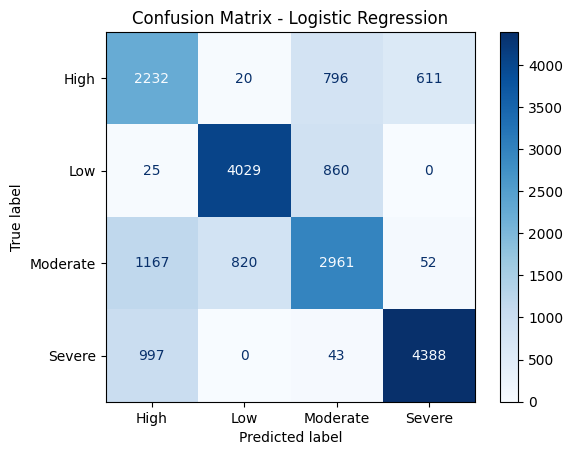

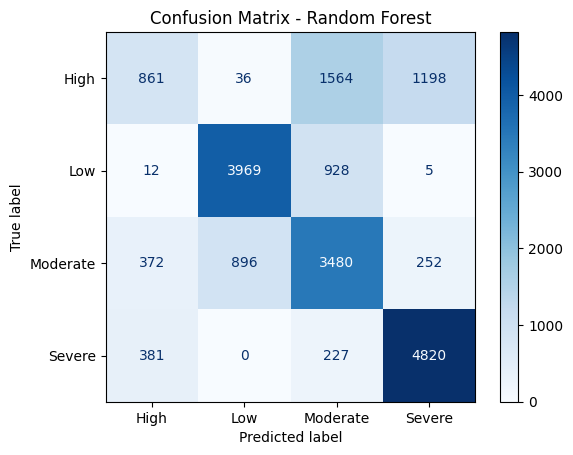

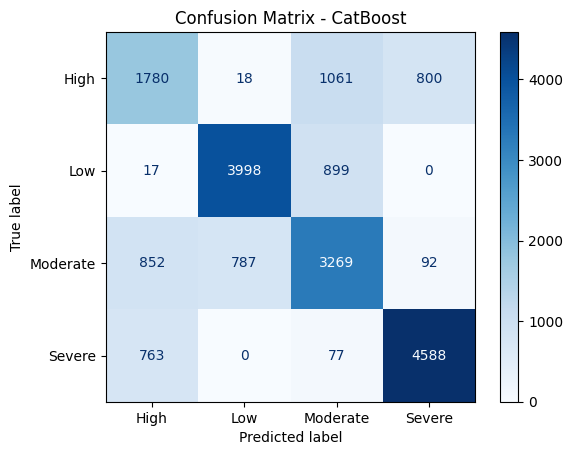

In [ ]:
models = {
    'Logistic Regression': y_pred_log,
    'Random Forest': y_pred_rf,
    'CatBoost': y_pred_cat
}
for name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['High', 'Low', 'Moderate', 'Severe']
    )

    disp.plot(cmap='Blues', values_format='d')
    disp.ax_.grid(False)
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

3.3. Feature Importance

,Feature,Importance
0,numeric__stress_score,40.424233
1,numeric__phq9_score,16.837308
2,numeric__gad7_score,14.879705
3,numeric__work_hours_per_week,8.464863
4,numeric__sleep_hours_per_night,6.692636
5,numeric__deadline_pressure_score,6.205047
6,categorical__work_mode_Remote,1.504198
7,numeric__job_change_intention,1.127757
8,numeric__seeks_mental_health_support,1.011824
9,categorical__gender_Female,0.670031


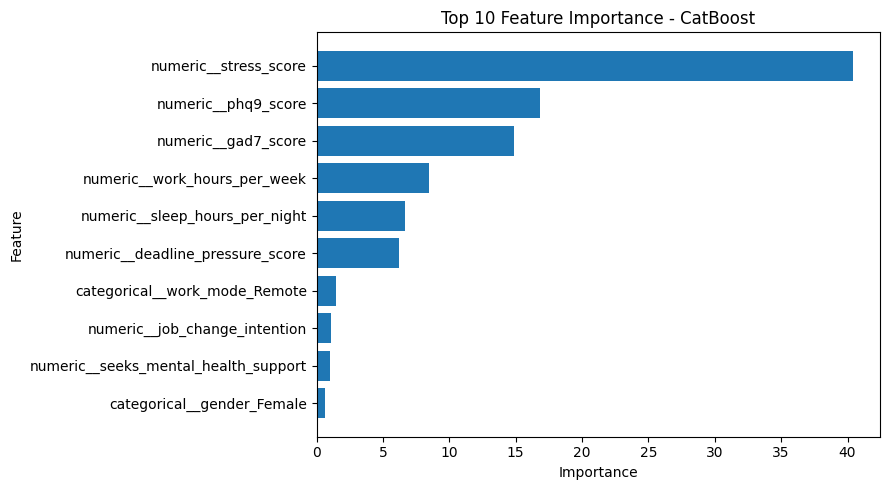

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.feature_importances_
})

# Sắp xếp từ quan trọng nhất đến thấp nhất
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# Lấy Top 10
top10_features = feature_importance.head(10)

plt.figure(figsize=(9, 5))

plt.barh(
    top10_features['Feature'][::-1],
    top10_features['Importance'][::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance - CatBoost')
plt.grid(False)
plt.tight_layout()
plt.show()

3.4. ROC-AUC

In [48]:
from sklearn.preprocessing import label_binarize

classes = ['High', 'Low', 'Moderate', 'Severe']

# Chuyển y_test thành dạng nhị phân
y_test_bin = label_binarize(y_test, classes=classes)

# Xác suất dự đoán
log_prob = log_model.predict_proba(X_test_log)
rf_prob = rf_model.predict_proba(X_test)
cat_prob = cat_model.predict_proba(X_test)

# ROC-AUC Logistic Regression
auc_log = roc_auc_score(
    y_test_bin,
    log_prob,
    multi_class='ovr',
    average='weighted'
)

# ROC-AUC Random Forest
auc_rf = roc_auc_score(
    y_test_bin,
    rf_prob,
    multi_class='ovr',
    average='weighted'
)

# ROC-AUC CatBoost
auc_cat = roc_auc_score(
    y_test_bin,
    cat_prob,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Logistic Regression:", round(auc_log, 4))
print("ROC-AUC Random Forest:", round(auc_rf, 4))
print("ROC-AUC CatBoost:", round(auc_cat, 4))

results['ROC-AUC'] = [
    auc_log,
    auc_rf,
    auc_cat
]

results = results.round(4)
results

ROC-AUC Logistic Regression: 0.9197
ROC-AUC Random Forest: 0.9074
ROC-AUC CatBoost: 0.919


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7163,0.7266,0.7163,0.7200,0.9197
1,Random Forest,0.6910,0.6786,0.6910,0.6708,0.9074
2,CatBoost,0.7176,0.7170,0.7176,0.7170,0.9190


3.5. Kiểm tra Overfitting

In [ ]:
# Logistic Regression
log_train_acc = accuracy_score(y_train, log_model.predict(X_train_log))
log_test_acc = accuracy_score(y_test, y_pred_log)

# Random Forest
rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc = accuracy_score(y_test, y_pred_rf)

# CatBoost
cat_train_acc = accuracy_score(y_train, cat_model.predict(X_train).ravel())
cat_test_acc = accuracy_score(y_test, y_pred_cat)

# Tạo bảng
overfit_check = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'CatBoost'
    ],
    'Train Accuracy': [
        log_train_acc,
        rf_train_acc,
        cat_train_acc
    ],
    'Test Accuracy': [
        log_test_acc,
        rf_test_acc,
        cat_test_acc
    ]
})

overfit_check['Gap'] = (overfit_check['Train Accuracy'] - overfit_check['Test Accuracy'])

overfit_check.round(4)

,Model,Train Accuracy,Test Accuracy,Gap
0,Logistic Regression,0.7162,0.7163,-0.0001
1,Random Forest,0.7293,0.6910,0.0383
2,CatBoost,0.7214,0.7176,0.0038


In [50]:
# Lấy 10 mẫu từ tập Test
sample = X_test.head(10)

# Dự đoán mức độ Burnout
predicted = cat_model.predict(sample).ravel()

# Xác suất dự đoán
probabilities = cat_model.predict_proba(sample)

# Tạo bảng kết quả
prediction_result = pd.DataFrame({
    'Thực tế': y_test.head(10).values,
    'Dự đoán': predicted,
    'Độ tin cậy (%)': probabilities.max(axis=1) * 100
})

prediction_result['Độ tin cậy (%)'] = prediction_result['Độ tin cậy (%)'].round(2)

display(prediction_result)

,Thực tế,Dự đoán,Độ tin cậy (%)
0,Moderate,Moderate,60.51
1,Moderate,Moderate,54.89
2,Severe,Severe,70.50
3,Severe,Severe,93.17
4,Low,Low,92.70
5,Severe,Severe,92.95
6,Severe,Severe,98.72
7,Moderate,Moderate,66.66
8,High,Severe,51.82
9,High,High,55.42


4. Mô hình dự đoán

In [51]:
preprocessor = joblib.load("burnout_preprocessor.joblib")

In [52]:
new_person = pd.DataFrame([{
    "age": 20,
    "gender": "Female",
    "survey_year": 2026,
    "country": 'Vietnam',
    "job_role": "Data Analyst",
    "seniority_level": "Junior",
    "years_experience": 2,
    "work_mode": "Hybrid",
    "salary_usd": 50000,
    "work_hours_per_week": 15,
    "sleep_hours_per_night": 6.5,
    "uses_therapy": 0,
    "ai_tools_daily": 1,
    "deadline_pressure_score": 5,
    "stress_score": 5,
    "phq9_score": 8,
    "gad7_score": 9,
    "seeks_mental_health_support": 0,
    "job_change_intention": 1
}])
display(new_person)

,age,gender,survey_year,country,job_role,seniority_level,years_experience,work_mode,salary_usd,work_hours_per_week,sleep_hours_per_night,uses_therapy,ai_tools_daily,deadline_pressure_score,stress_score,phq9_score,gad7_score,seeks_mental_health_support,job_change_intention
0,20,Female,2026,Vietnam,Data Analyst,Junior,2,Hybrid,50000,15,6.5,0,1,5,5,8,9,0,1


In [53]:
# Tiền xử lý thông tin người mới
new_person_processed = pd.DataFrame(
    preprocessor.transform(new_person),
    columns=preprocessor.get_feature_names_out()
)
prediction = log_model.predict(new_person_processed)

predicted_level = prediction[0]

print("Mức độ Burnout dự đoán:", predicted_level)

Mức độ Burnout dự đoán: Severe


6. Visual 

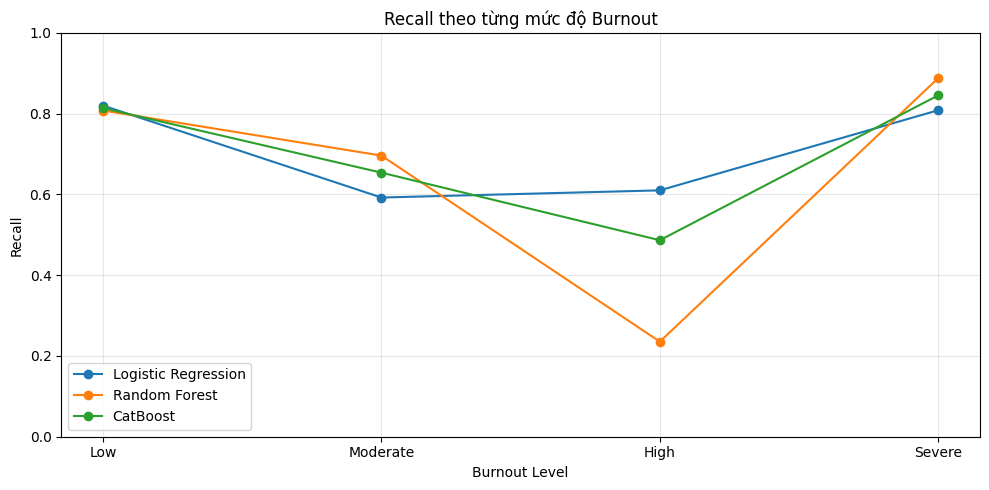

In [58]:
# Thứ tự các lớp
classes = ['Low', 'Moderate', 'High', 'Severe']

# Recall từng lớp của từng model
recall_log = recall_score(y_test, y_pred_log,
    labels=classes,
    average=None
)
recall_rf = recall_score(y_test, y_pred_rf,
    labels=classes,
    average=None
)
recall_cat = recall_score(y_test, y_pred_cat,
    labels=classes,
    average=None
)
recall_df = pd.DataFrame({
    'Burnout Level': classes,
    'Logistic Regression': recall_log,
    'Random Forest': recall_rf,
    'CatBoost': recall_cat
})

plt.figure(figsize=(10, 5))
plt.plot(
    recall_df['Burnout Level'],
    recall_df['Logistic Regression'],
    marker='o',
    label='Logistic Regression'
)
plt.plot(
    recall_df['Burnout Level'],
    recall_df['Random Forest'],
    marker='o',
    label='Random Forest'
)
plt.plot(
    recall_df['Burnout Level'],
    recall_df['CatBoost'],
    marker='o',
    label='CatBoost'
)
plt.title('Recall theo từng mức độ Burnout')
plt.xlabel('Burnout Level')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

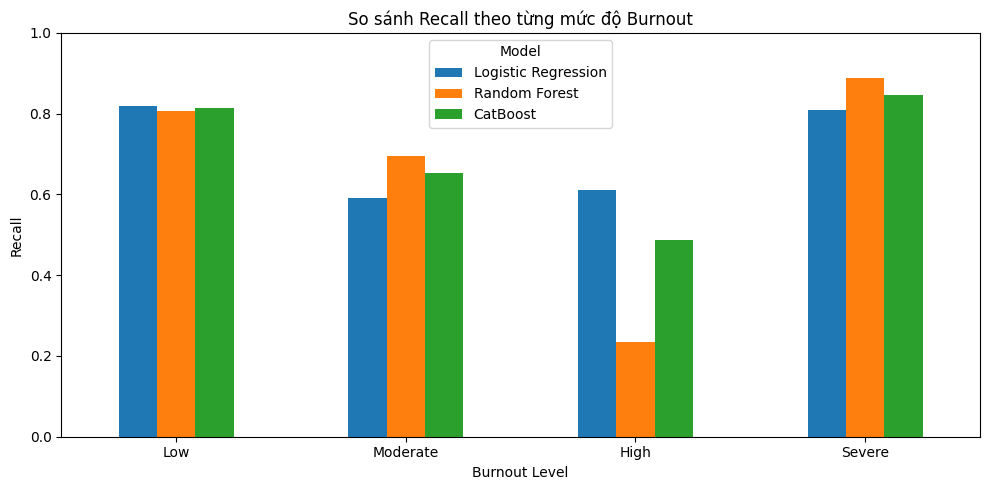

In [60]:
recall_df.set_index('Burnout Level').plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('So sánh Recall theo từng mức độ Burnout')
plt.xlabel('Burnout Level')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.tight_layout()
plt.show()